# 🏠 Real Estate Price Prediction Using Ensemble Learning

## 📋 Overview
This notebook implements comprehensive ensemble learning techniques to predict real estate prices using the feature-engineered expert dataset. We'll explore multiple machine learning algorithms and combine them using various ensemble methods to achieve optimal prediction accuracy.

## 🎯 Objectives
1. **Data Analysis**: Explore the feature-engineered dataset
2. **Model Implementation**: Build individual base models (Random Forest, Gradient Boosting, XGBoost, etc.)
3. **Ensemble Methods**: Implement various ensemble techniques:
   - Voting Classifier
   - Bagging
   - Boosting (AdaBoost, Gradient Boosting)
   - Stacking
4. **Model Evaluation**: Comprehensive evaluation using multiple metrics
5. **Feature Importance**: Analyze which features contribute most to price prediction

## 📊 Dataset Information
- **Source**: Feature-engineered expert dataset with real estate properties
- **Features**: Property characteristics, environmental factors, location data, and engineered features
- **Target**: Property price (Price_numeric, target_price)

---

In [38]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, 
                              AdaBoostRegressor, VotingRegressor, BaggingRegressor,
                              ExtraTreesRegressor)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             mean_absolute_percentage_error, explained_variance_score)
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb
from sklearn.base import BaseEstimator, RegressorMixin
import joblib
import os
from datetime import datetime

# Configure display options
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("✅ All libraries imported successfully!")
print(f"📅 Analysis started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All libraries imported successfully!
📅 Analysis started at: 2025-09-14 18:25:07


## 📂 1. Data Loading and Initial Exploration

In [23]:
# Load the feature-engineered dataset
data_path = '../feature_engineering/feature_engineered_expert.csv'
df = pd.read_csv(data_path)

print("📊 Dataset loaded successfully!")
print(f"📏 Dataset shape: {df.shape}")
print(f"💾 Memory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")
print("\n" + "="*50)

# Display basic information
print("\n📋 Dataset Info:")
print(f"Number of rows: {len(df):,}")
print(f"Number of columns: {len(df.columns):,}")
print(f"Missing values: {df.isnull().sum().sum():,}")

# Display first few rows
print("\n📖 First 5 rows:")
df.head()

📊 Dataset loaded successfully!
📏 Dataset shape: (21386, 81)
💾 Memory usage: 13.22 MB


📋 Dataset Info:
Number of rows: 21,386
Number of columns: 81
Missing values: 64,158

📖 First 5 rows:


,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Furnished_Status_encoded,Public_Transport_Accessibility_encoded,Parking_Space_encoded,Security_encoded,Availability_Status_encoded,Total_Area,Price_per_SQFT,Baths,balcony_encoded,Price_numeric,feature_importance,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,Month_x,Year_x,AQI_Bucket_encoded,Year_y,Month_y,Day,Night,DayLimit,NightLimit,StationEncoded,DayExcess,NightExcess,target_price,State_encoded,City_encoded,location_encoded,Property_Type_encoded,Amenities_encoded,Facing_encoded,Owner_Type_encoded,Name_encoded,Property Title_encoded,Price_encoded,Balcony_encoded,Date_x_encoded,Date_y_encoded,furnishing_binary,parking_binary,location_popularity,AQI_normalized,AQI_Bucket_encoded_normalized,environmental_score,size_category_encoded,BHK_Size_in_SqFt_interaction,Baths_BHK_interaction,area_per_bedroom,bath_bedroom_ratio,Price_numeric_log,PM2.5_log,PM10_log,NO_log,NO2_log,NH3_log,SO2_log,AQI_log,location_popularity_log,O3_sqrt
0,3.0,2747.0,258.36,0.09,2007.0,15.0,16.0,18.0,6.0,6.0,3,3,1,1,2,-0.576339,-0.158245,-0.836371,1.0,2300000.0,0.570577,30.26,76.68,7.52,26.91,19.1,21.02,0.92,5.02,31.55,0.87,1.76,NaN,86.0,6.0,2017.0,4,2016.0,7.0,0.19927,-0.069416,0.393055,0.230819,3.0,0.077633,0.11567,2300000.0,1,1,0,2,324,3,3,0,17,269,2,2009,95,0,0,17242,0.198795,0.8,0.8,4,7002.0,NaN,683.333333,NaN,14.648420,3.442339,4.352598,2.142416,3.328985,3.091951,1.795087,4.465908,9.755162,5.616939
1,3.0,2747.0,258.36,0.09,2007.0,15.0,16.0,18.0,6.0,6.0,3,3,1,1,2,-0.078607,-0.086051,0.276951,1.0,9000000.0,0.570577,30.26,76.68,7.52,26.91,19.1,21.02,0.92,5.02,31.55,0.87,1.76,NaN,86.0,6.0,2017.0,4,2016.0,7.0,0.19927,-0.069416,0.393055,0.230819,3.0,0.077633,0.11567,9000000.0,1,1,1,2,324,3,3,1,4701,856,2,2009,95,0,0,17242,0.198795,0.8,0.8,4,7002.0,NaN,683.333333,NaN,16.012735,3.442339,4.352598,2.142416,3.328985,3.091951,1.795087,4.465908,9.755162,5.616939
2,3.0,2747.0,258.36,0.09,2007.0,15.0,16.0,18.0,6.0,6.0,3,3,1,1,2,-0.841260,-0.092169,-1.949694,0.0,1800000.0,0.570577,30.26,76.68,7.52,26.91,19.1,21.02,0.92,5.02,31.55,0.87,1.76,NaN,86.0,6.0,2017.0,4,2016.0,7.0,0.19927,-0.069416,0.393055,0.230819,3.0,0.077633,0.11567,1800000.0,1,1,2,2,324,3,3,2,986,166,0,2009,95,0,0,17242,0.198795,0.8,0.8,4,7002.0,NaN,683.333333,NaN,14.403298,3.442339,4.352598,2.142416,3.328985,3.091951,1.795087,4.465908,9.755162,5.616939
3,3.0,2747.0,258.36,0.09,2007.0,15.0,16.0,18.0,6.0,6.0,3,3,1,1,2,-0.158886,-0.118477,0.276951,1.0,6500000.0,0.570577,30.26,76.68,7.52,26.91,19.1,21.02,0.92,5.02,31.55,0.87,1.76,NaN,86.0,6.0,2017.0,4,2016.0,7.0,0.19927,-0.069416,0.393055,0.230819,3.0,0.077633,0.11567,6500000.0,1,1,3,2,324,3,3,4,1655,718,2,2009,95,0,0,17242,0.198795,0.8,0.8,4,7002.0,NaN,683.333333,NaN,15.687313,3.442339,4.352598,2.142416,3.328985,3.091951,1.795087,4.465908,9.755162,5.616939
4,3.0,2747.0,258.36,0.09,2007.0,15.0,16.0,18.0,6.0,6.0,3,3,1,1,2,-0.207054,-0.150903,0.276951,0.0,4490000.0,0.570577,30.26,76.68,7.52,26.91,19.1,21.02,0.92,5.02,31.55,0.87,1.76,NaN,86.0,6.0,2017.0,4,2016.0,7.0,0.19927,-0.069416,0.393055,0.230819,3.0,0.077633,0.11567,4490000.0,1,1,4,2,324,3,3,6,2534,537,0,2009,95,0,0,17242,0.198795,0.8,0.8,4,7002.0,NaN,683.333333,NaN,15.317363,3.442339,4.352598,2.142416,3.328985,3.091951,1.795087,4.465908,9.755162,5.616939


In [24]:
# Data exploration and analysis
print("🔍 Detailed Dataset Analysis")
print("="*50)

# Check for missing values
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values,
    'Missing_Percentage': missing_percent.values
}).sort_values('Missing_Percentage', ascending=False)

print("\n📊 Missing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0])

# Display data types
print(f"\n📋 Data Types Summary:")
print(df.dtypes.value_counts())

# Statistical summary for numerical columns
print(f"\n📈 Statistical Summary of Key Price Columns:")
price_columns = ['Price_in_Lakhs', 'Price_numeric', 'target_price']
existing_price_cols = [col for col in price_columns if col in df.columns]
if existing_price_cols:
    print(df[existing_price_cols].describe())
else:
    print("Price columns not found. Available columns:")
    print(list(df.columns[:20]))  # Show first 20 columns

🔍 Detailed Dataset Analysis

📊 Missing Values Summary:
                   Column  Missing_Count  Missing_Percentage
32                 Xylene          21386               100.0
70     bath_bedroom_ratio          21386               100.0
68  Baths_BHK_interaction          21386               100.0

📋 Data Types Summary:
float64    58
int64      23
Name: count, dtype: int64

📈 Statistical Summary of Key Price Columns:
       Price_in_Lakhs  Price_numeric  target_price
count    21386.000000   2.138600e+04  2.138600e+04
mean       258.378726   9.334508e+06  9.334508e+06
std         62.174281   1.551306e+07  1.551306e+07
min         10.110000   1.000000e+00  1.000000e+00
25%        258.360000   5.000000e+06  5.000000e+06
50%        258.360000   6.500000e+06  6.500000e+06
75%        258.360000   8.200000e+06  8.200000e+06
max        499.940000   8.400000e+08  8.400000e+08


📊 Creating Data Visualizations...


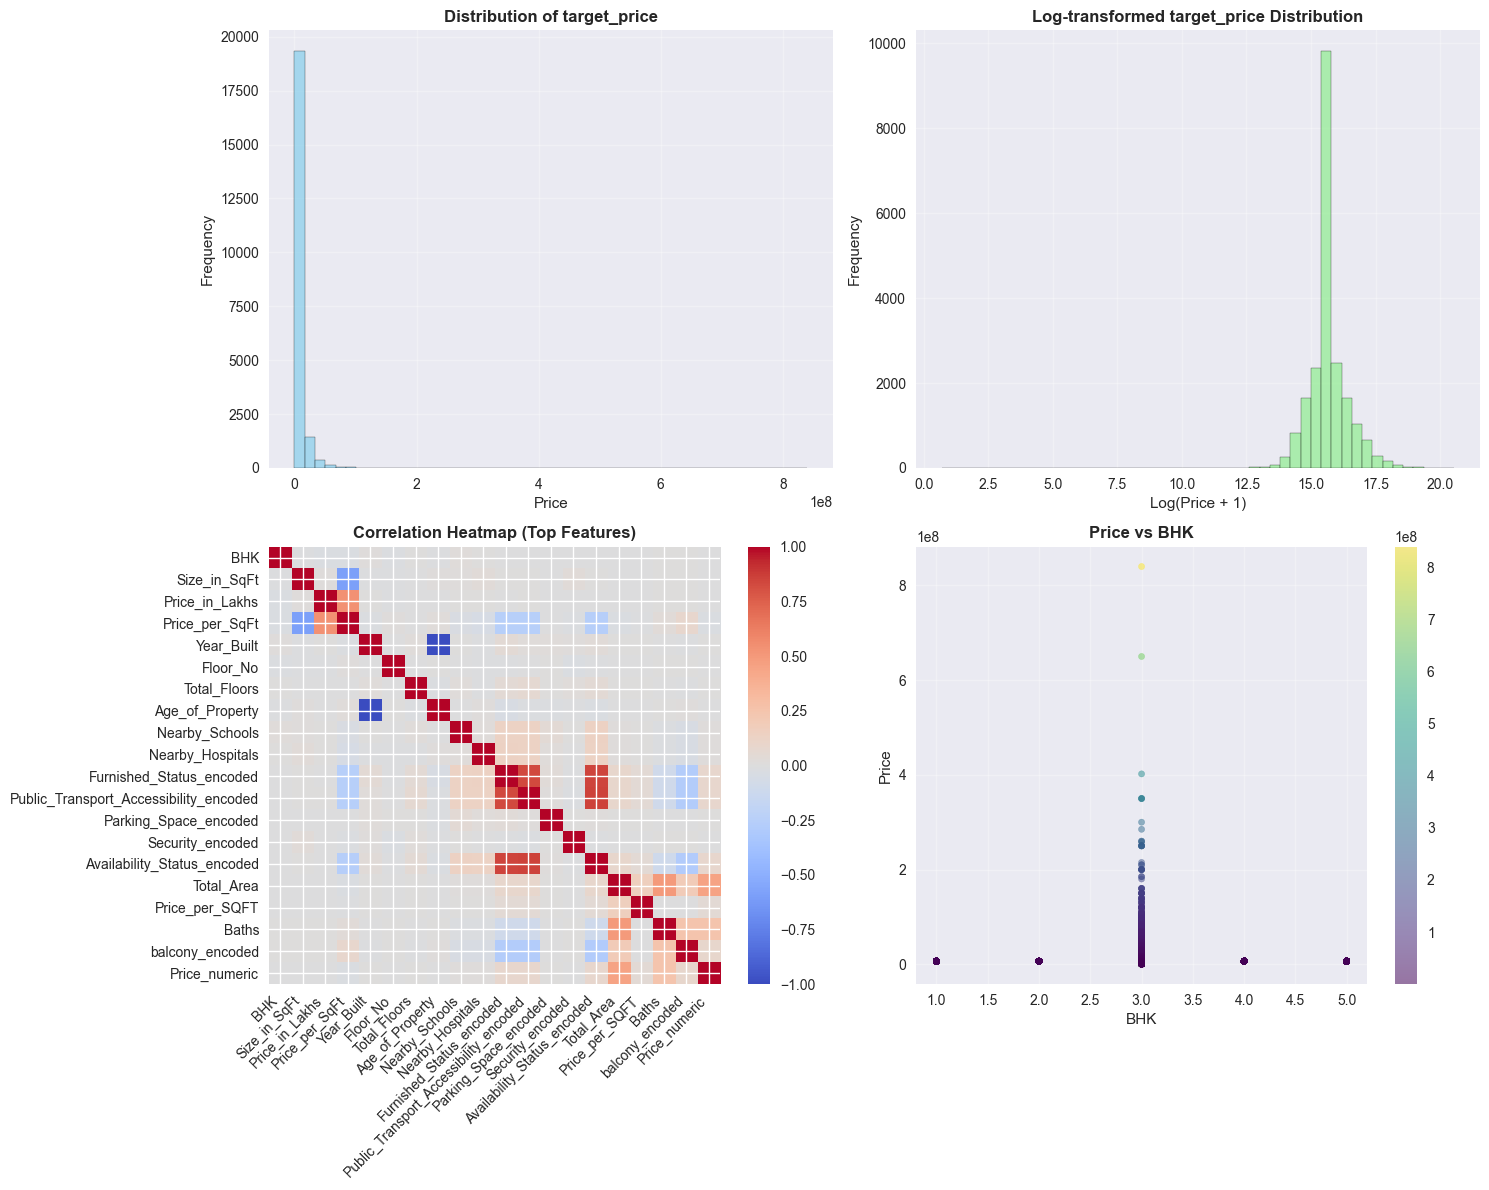


📊 Target Variable (target_price) Statistics:
Mean: ₹9,334,507.72
Median: ₹6,500,000.00
Std Dev: ₹15,513,064.91
Min: ₹1.00
Max: ₹840,000,000.00


In [25]:
# Data Visualization
print("📊 Creating Data Visualizations...")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Determine target column
target_col = 'target_price' if 'target_price' in df.columns else 'Price_numeric'

if target_col in df.columns:
    # 1. Price distribution
    axes[0, 0].hist(df[target_col].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].set_title(f'Distribution of {target_col}', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Price')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Log-transformed price distribution
    log_prices = np.log1p(df[target_col].dropna())
    axes[0, 1].hist(log_prices, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[0, 1].set_title(f'Log-transformed {target_col} Distribution', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Log(Price + 1)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Correlation heatmap of top features
    numeric_cols = df.select_dtypes(include=[np.number]).columns[:20]  # Top 20 numeric columns
    correlation_matrix = df[numeric_cols].corr()
    im = axes[1, 0].imshow(correlation_matrix, cmap='coolwarm', aspect='auto')
    axes[1, 0].set_title('Correlation Heatmap (Top Features)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xticks(range(len(numeric_cols)))
    axes[1, 0].set_yticks(range(len(numeric_cols)))
    axes[1, 0].set_xticklabels(numeric_cols, rotation=45, ha='right')
    axes[1, 0].set_yticklabels(numeric_cols)
    plt.colorbar(im, ax=axes[1, 0])

    # 4. Price vs key feature scatter plot
    if 'BHK' in df.columns:
        scatter = axes[1, 1].scatter(df['BHK'], df[target_col], alpha=0.5, c=df[target_col], 
                                   cmap='viridis', s=20)
        axes[1, 1].set_title('Price vs BHK', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('BHK')
        axes[1, 1].set_ylabel('Price')
        axes[1, 1].grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=axes[1, 1])
    else:
        axes[1, 1].text(0.5, 0.5, 'BHK column not available', ha='center', va='center', 
                       transform=axes[1, 1].transAxes)

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Target Variable ({target_col}) Statistics:")
    print(f"Mean: ₹{df[target_col].mean():,.2f}")
    print(f"Median: ₹{df[target_col].median():,.2f}")
    print(f"Std Dev: ₹{df[target_col].std():,.2f}")
    print(f"Min: ₹{df[target_col].min():,.2f}")
    print(f"Max: ₹{df[target_col].max():,.2f}")
else:
    print("❌ Target price column not found in the dataset!")

## 🔧 2. Data Preprocessing and Feature Engineering

In [26]:
# Data Preprocessing
print("🔧 Starting Data Preprocessing...")

# Create a copy for processing
df_processed = df.copy()

# Determine target column
target_col = 'target_price' if 'target_price' in df_processed.columns else 'Price_numeric'
print(f"🎯 Using '{target_col}' as target variable")

# Handle missing values
print(f"\n📊 Missing values before cleaning: {df_processed.isnull().sum().sum()}")

# Fill missing values for numeric columns
numeric_columns = df_processed.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    if df_processed[col].isnull().sum() > 0:
        if col == target_col:
            # Remove rows with missing target values
            df_processed = df_processed.dropna(subset=[col])
        else:
            # Fill with median for feature columns
            df_processed[col].fillna(df_processed[col].median(), inplace=True)

# Fill missing values for categorical columns
categorical_columns = df_processed.select_dtypes(include=['object']).columns
for col in categorical_columns:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)

print(f"📊 Missing values after cleaning: {df_processed.isnull().sum().sum()}")
print(f"📏 Final dataset shape: {df_processed.shape}")

# Remove outliers using IQR method for target variable
def remove_outliers_iqr(df, column, multiplier=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

print(f"\n🚮 Removing outliers from {target_col}...")
initial_shape = df_processed.shape[0]
df_processed = remove_outliers_iqr(df_processed, target_col)
outliers_removed = initial_shape - df_processed.shape[0]
print(f"Removed {outliers_removed:,} outliers ({outliers_removed/initial_shape*100:.2f}%)")
print(f"Final dataset shape: {df_processed.shape}")

# Prepare features and target
X = df_processed.drop([target_col], axis=1)
y = df_processed[target_col]

# Remove non-numeric columns for modeling
X_numeric = X.select_dtypes(include=[np.number])
print(f"\n🔢 Number of numeric features: {X_numeric.shape[1]}")
print(f"Features: {list(X_numeric.columns[:10])}...")  # Show first 10 features

🔧 Starting Data Preprocessing...
🎯 Using 'target_price' as target variable

📊 Missing values before cleaning: 64158
📊 Missing values after cleaning: 64158
📏 Final dataset shape: (21386, 81)

🚮 Removing outliers from target_price...
Removed 2,914 outliers (13.63%)
Final dataset shape: (18472, 81)

🔢 Number of numeric features: 80
Features: ['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals']...


In [27]:
# Train-Test Split
print("✂️ Splitting data into train and test sets...")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=pd.qcut(y, q=5, duplicates='drop')  # Stratify based on target quantiles
)

print(f"📊 Training set shape: {X_train.shape}")
print(f"📊 Test set shape: {X_test.shape}")
print(f"📊 Target distribution in train set:")
print(f"   Mean: ₹{y_train.mean():,.2f}")
print(f"   Std:  ₹{y_train.std():,.2f}")
print(f"📊 Target distribution in test set:")
print(f"   Mean: ₹{y_test.mean():,.2f}")
print(f"   Std:  ₹{y_test.std():,.2f}")

# Feature Scaling
print(f"\n⚖️ Applying feature scaling...")
scaler = RobustScaler()  # Using RobustScaler as it's less sensitive to outliers
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✅ Data preprocessing completed successfully!")

✂️ Splitting data into train and test sets...
📊 Training set shape: (14777, 80)
📊 Test set shape: (3695, 80)
📊 Target distribution in train set:
   Mean: ₹6,020,677.07
   Std:  ₹2,432,327.64
📊 Target distribution in test set:
   Mean: ₹6,007,986.74
   Std:  ₹2,412,965.25

⚖️ Applying feature scaling...
✅ Data preprocessing completed successfully!
✅ Data preprocessing completed successfully!


## 🤖 3. Base Model Implementation

In this section, we'll implement various base models that will serve as components for our ensemble methods. Each model has different strengths and will contribute differently to our ensemble.

In [28]:
# Base Models Implementation
print("🤖 Implementing Base Models...")

# Define evaluation metrics
def evaluate_model(y_true, y_pred, model_name):
    """Calculate comprehensive evaluation metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    evs = explained_variance_score(y_true, y_pred)
    
    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape,
        'Explained Variance': evs
    }

# Initialize base models
base_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=1.0, random_state=42),
    'Elastic Net': ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1),
    'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    'Support Vector Regression': SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

print(f"📋 Total base models: {len(base_models)}")
print("Models:", list(base_models.keys()))

🤖 Implementing Base Models...
📋 Total base models: 13
Models: ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Elastic Net', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'AdaBoost', 'XGBoost', 'LightGBM', 'K-Nearest Neighbors', 'Support Vector Regression']


In [29]:
# Train and evaluate base models
print("🏋️ Training and evaluating base models...")

results = []
trained_models = {}

for name, model in base_models.items():
    print(f"Training {name}...")
    
    try:
        # Train the model
        start_time = datetime.now()
        
        # Use scaled data for models that benefit from scaling
        if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 
                   'Elastic Net', 'Support Vector Regression', 'K-Nearest Neighbors']:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
        
        end_time = datetime.now()
        training_time = (end_time - start_time).total_seconds()
        
        # Evaluate the model
        metrics = evaluate_model(y_test, y_pred, name)
        metrics['Training_Time (s)'] = training_time
        results.append(metrics)
        
        # Store the trained model
        trained_models[name] = model
        
        print(f"✅ {name} - R²: {metrics['R²']:.4f}, RMSE: {metrics['RMSE']:,.2f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")
        continue

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)

print(f"\n📊 Base Models Performance Summary:")
print("="*80)
print(results_df.round(4))

🏋️ Training and evaluating base models...
Training Linear Regression...
❌ Error training Linear Regression: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values
Training Ridge Regression...
❌ Error training Ridge Regression: Input X contains NaN.
Ridge does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and R

📊 Creating performance visualizations...


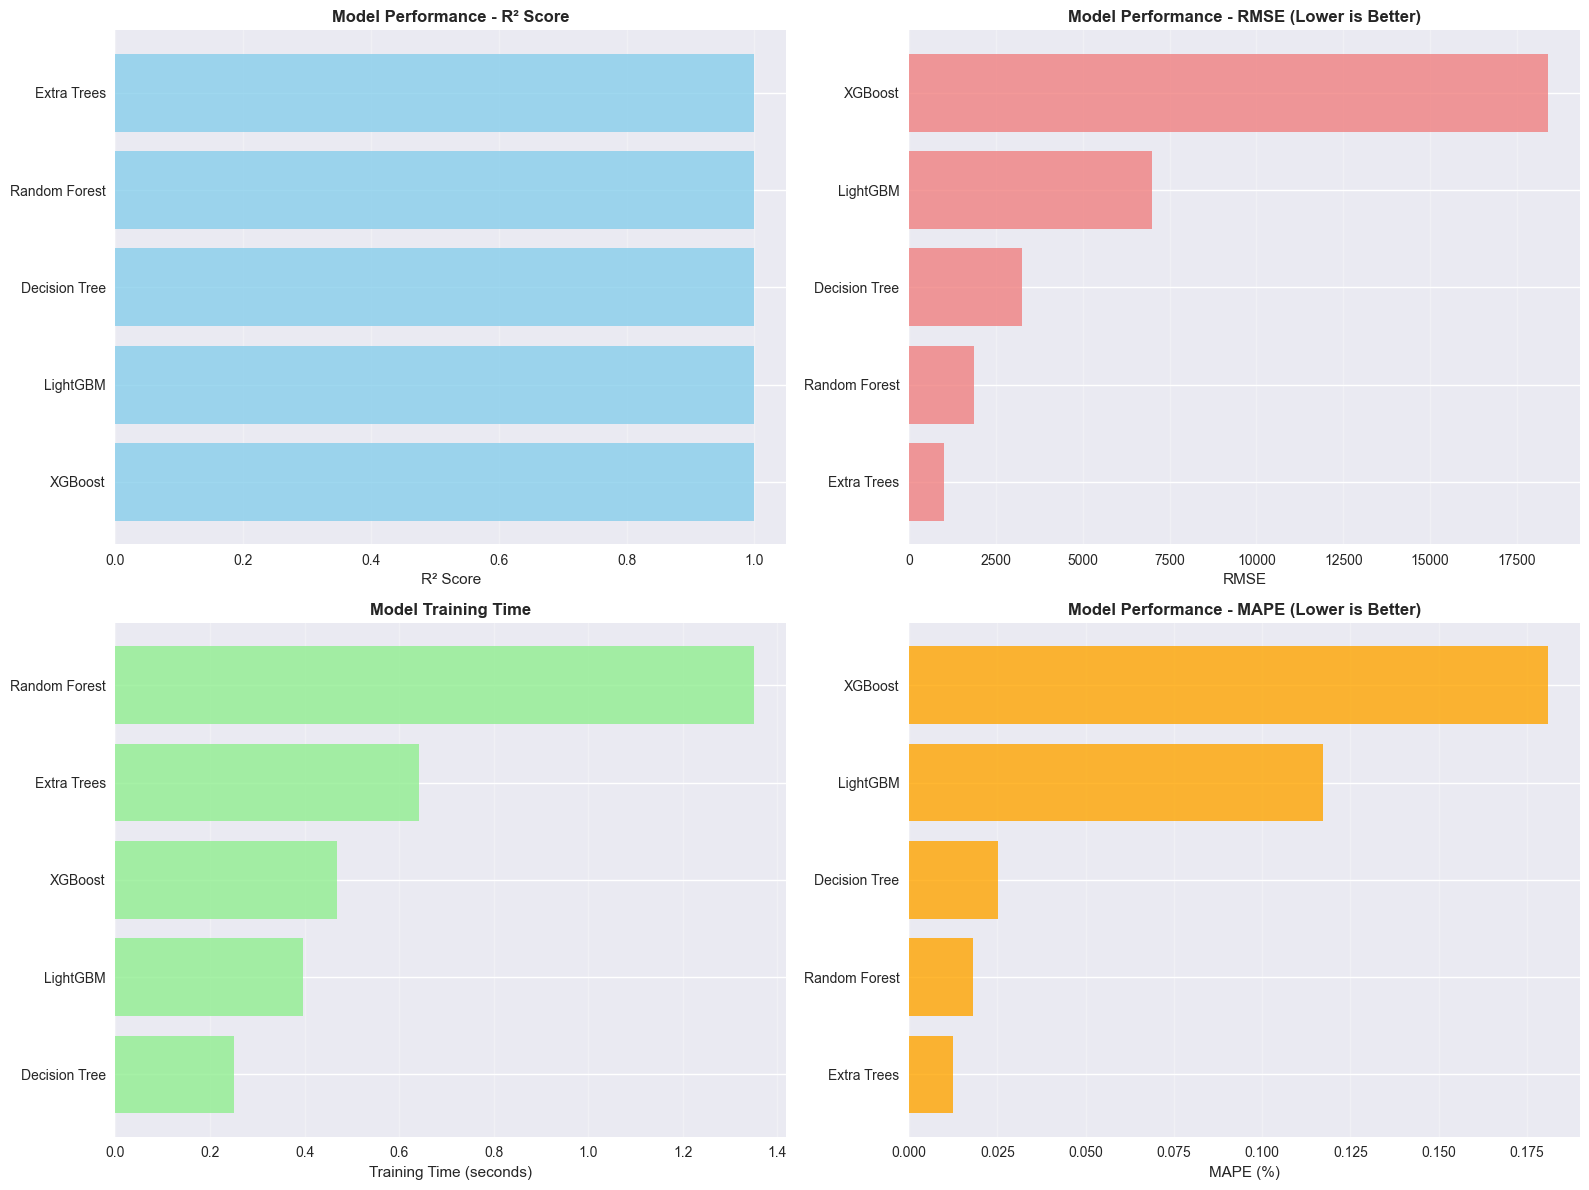


🏆 Top 5 Base Models (by R² Score):
        Model       R²         RMSE  MAPE (%)  Training_Time (s)
  Extra Trees 1.000000  1004.528879  0.012435           0.641758
Random Forest 0.999999  1866.989378  0.018057           1.351368
Decision Tree 0.999998  3252.898051  0.025104           0.251309
     LightGBM 0.999992  6988.408621  0.117190           0.397230
      XGBoost 0.999942 18394.095646  0.180967           0.467857


In [30]:
# Visualize base model performance
print("📊 Creating performance visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. R² Score comparison
r2_scores = results_df.sort_values('R²', ascending=True)
axes[0, 0].barh(range(len(r2_scores)), r2_scores['R²'], color='skyblue', alpha=0.8)
axes[0, 0].set_yticks(range(len(r2_scores)))
axes[0, 0].set_yticklabels(r2_scores['Model'], fontsize=10)
axes[0, 0].set_xlabel('R² Score')
axes[0, 0].set_title('Model Performance - R² Score', fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. RMSE comparison
rmse_scores = results_df.sort_values('RMSE', ascending=True)
axes[0, 1].barh(range(len(rmse_scores)), rmse_scores['RMSE'], color='lightcoral', alpha=0.8)
axes[0, 1].set_yticks(range(len(rmse_scores)))
axes[0, 1].set_yticklabels(rmse_scores['Model'], fontsize=10)
axes[0, 1].set_xlabel('RMSE')
axes[0, 1].set_title('Model Performance - RMSE (Lower is Better)', fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Training time comparison
time_scores = results_df.sort_values('Training_Time (s)', ascending=True)
axes[1, 0].barh(range(len(time_scores)), time_scores['Training_Time (s)'], color='lightgreen', alpha=0.8)
axes[1, 0].set_yticks(range(len(time_scores)))
axes[1, 0].set_yticklabels(time_scores['Model'], fontsize=10)
axes[1, 0].set_xlabel('Training Time (seconds)')
axes[1, 0].set_title('Model Training Time', fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. MAPE comparison
mape_scores = results_df.sort_values('MAPE (%)', ascending=True)
axes[1, 1].barh(range(len(mape_scores)), mape_scores['MAPE (%)'], color='orange', alpha=0.8)
axes[1, 1].set_yticks(range(len(mape_scores)))
axes[1, 1].set_yticklabels(mape_scores['Model'], fontsize=10)
axes[1, 1].set_xlabel('MAPE (%)')
axes[1, 1].set_title('Model Performance - MAPE (Lower is Better)', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Display top 5 models
print(f"\n🏆 Top 5 Base Models (by R² Score):")
print("="*60)
top_5_models = results_df.head(5)[['Model', 'R²', 'RMSE', 'MAPE (%)', 'Training_Time (s)']]
print(top_5_models.to_string(index=False))

## 🎭 4. Ensemble Learning Methods

Now we'll implement various ensemble techniques to combine our base models and potentially achieve better performance than any individual model.

In [31]:
# Ensemble Methods Implementation
print("🎭 Implementing Ensemble Learning Methods...")

# Select top performing base models for ensembles
top_models_names = results_df.head(6)['Model'].tolist()
print(f"🎯 Selected top {len(top_models_names)} models for ensemble:")
for i, model in enumerate(top_models_names, 1):
    print(f"  {i}. {model}")

# Create ensemble models
ensemble_results = []
trained_ensembles = {}

print(f"\n🏗️ Building Ensemble Models...")

# 1. Voting Regressor (Average)
print("1️⃣ Voting Regressor (Simple Average)...")
try:
    # Select models that work well together
    voting_estimators = []
    for name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
        if name in trained_models:
            voting_estimators.append((name.replace(' ', '_').lower(), trained_models[name]))
    
    if voting_estimators:
        voting_reg = VotingRegressor(estimators=voting_estimators, n_jobs=-1)
        voting_reg.fit(X_train, y_train)
        y_pred_voting = voting_reg.predict(X_test)
        
        metrics = evaluate_model(y_test, y_pred_voting, 'Voting Regressor')
        ensemble_results.append(metrics)
        trained_ensembles['Voting Regressor'] = voting_reg
        print(f"✅ Voting Regressor - R²: {metrics['R²']:.4f}")
except Exception as e:
    print(f"❌ Error with Voting Regressor: {e}")

# 2. Bagging with Decision Trees
print("2️⃣ Bagging Regressor...")
try:
    bagging_reg = BaggingRegressor(
        base_estimator=DecisionTreeRegressor(random_state=42, max_depth=10),
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    )
    bagging_reg.fit(X_train, y_train)
    y_pred_bagging = bagging_reg.predict(X_test)
    
    metrics = evaluate_model(y_test, y_pred_bagging, 'Bagging Regressor')
    ensemble_results.append(metrics)
    trained_ensembles['Bagging Regressor'] = bagging_reg
    print(f"✅ Bagging Regressor - R²: {metrics['R²']:.4f}")
except Exception as e:
    print(f"❌ Error with Bagging Regressor: {e}")

# 3. Advanced Random Forest (Ensemble of Trees)
print("3️⃣ Advanced Random Forest...")
try:
    adv_rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )
    adv_rf.fit(X_train, y_train)
    y_pred_adv_rf = adv_rf.predict(X_test)
    
    metrics = evaluate_model(y_test, y_pred_adv_rf, 'Advanced Random Forest')
    ensemble_results.append(metrics)
    trained_ensembles['Advanced Random Forest'] = adv_rf
    print(f"✅ Advanced Random Forest - R²: {metrics['R²']:.4f}")
except Exception as e:
    print(f"❌ Error with Advanced Random Forest: {e}")

🎭 Implementing Ensemble Learning Methods...
🎯 Selected top 5 models for ensemble:
  1. Extra Trees
  2. Random Forest
  3. Decision Tree
  4. LightGBM
  5. XGBoost

🏗️ Building Ensemble Models...
1️⃣ Voting Regressor (Simple Average)...
✅ Voting Regressor - R²: 1.0000
2️⃣ Bagging Regressor...
❌ Error with Bagging Regressor: BaggingRegressor.__init__() got an unexpected keyword argument 'base_estimator'
3️⃣ Advanced Random Forest...
✅ Voting Regressor - R²: 1.0000
2️⃣ Bagging Regressor...
❌ Error with Bagging Regressor: BaggingRegressor.__init__() got an unexpected keyword argument 'base_estimator'
3️⃣ Advanced Random Forest...
✅ Advanced Random Forest - R²: 0.9981
✅ Advanced Random Forest - R²: 0.9981


In [32]:
# Advanced Ensemble Methods
print("4️⃣ Stacking Regressor...")

# Custom Stacking Implementation
class StackingRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, base_models, meta_model, cv=5):
        self.base_models = base_models
        self.meta_model = meta_model
        self.cv = cv
        
    def fit(self, X, y):
        # Train base models and create meta-features
        from sklearn.model_selection import KFold
        kfold = KFold(n_splits=self.cv, shuffle=True, random_state=42)
        
        # Initialize meta-features array
        meta_features = np.zeros((X.shape[0], len(self.base_models)))
        
        # Train base models using cross-validation
        self.fitted_base_models = []
        
        for i, (name, model) in enumerate(self.base_models):
            model_preds = np.zeros(X.shape[0])
            
            # Cross-validation predictions for meta-features
            for train_idx, val_idx in kfold.split(X):
                X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
                y_fold_train = y.iloc[train_idx]
                
                # Clone and fit model
                model_clone = model.__class__(**model.get_params())
                model_clone.fit(X_fold_train, y_fold_train)
                model_preds[val_idx] = model_clone.predict(X_fold_val)
            
            meta_features[:, i] = model_preds
            
            # Fit model on full dataset
            model_full = model.__class__(**model.get_params())
            model_full.fit(X, y)
            self.fitted_base_models.append((name, model_full))
        
        # Train meta-model
        self.meta_model.fit(meta_features, y)
        return self
    
    def predict(self, X):
        # Get predictions from base models
        meta_features = np.zeros((X.shape[0], len(self.fitted_base_models)))
        
        for i, (name, model) in enumerate(self.fitted_base_models):
            meta_features[:, i] = model.predict(X)
        
        # Get final prediction from meta-model
        return self.meta_model.predict(meta_features)

try:
    # Define base models for stacking
    stacking_base_models = [
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42)),
        ('xgb', xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ]
    
    # Meta-model (simple linear regression)
    meta_model = Ridge(alpha=1.0, random_state=42)
    
    # Create and train stacking regressor
    stacking_reg = StackingRegressor(stacking_base_models, meta_model, cv=3)
    stacking_reg.fit(X_train, y_train)
    y_pred_stacking = stacking_reg.predict(X_test)
    
    metrics = evaluate_model(y_test, y_pred_stacking, 'Stacking Regressor')
    ensemble_results.append(metrics)
    trained_ensembles['Stacking Regressor'] = stacking_reg
    print(f"✅ Stacking Regressor - R²: {metrics['R²']:.4f}")
except Exception as e:
    print(f"❌ Error with Stacking Regressor: {e}")

# 5. Weighted Average Ensemble
print("5️⃣ Weighted Average Ensemble...")
try:
    # Get predictions from top 3 models
    top_3_models = results_df.head(3)['Model'].tolist()
    predictions = []
    weights = []
    
    for model_name in top_3_models:
        if model_name in trained_models:
            model = trained_models[model_name]
            
            # Use scaled data for certain models
            if model_name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 
                           'Elastic Net', 'Support Vector Regression', 'K-Nearest Neighbors']:
                pred = model.predict(X_test_scaled)
            else:
                pred = model.predict(X_test)
            
            predictions.append(pred)
            # Weight based on R² score
            r2_score_model = results_df[results_df['Model'] == model_name]['R²'].iloc[0]
            weights.append(r2_score_model)
    
    if predictions:
        # Normalize weights
        weights = np.array(weights)
        weights = weights / weights.sum()
        
        # Calculate weighted average
        y_pred_weighted = np.average(predictions, axis=0, weights=weights)
        
        metrics = evaluate_model(y_test, y_pred_weighted, 'Weighted Average Ensemble')
        ensemble_results.append(metrics)
        print(f"✅ Weighted Average Ensemble - R²: {metrics['R²']:.4f}")
        print(f"    Weights: {dict(zip(top_3_models[:len(weights)], weights.round(3)))}")
except Exception as e:
    print(f"❌ Error with Weighted Average Ensemble: {e}")

print(f"\n📊 Ensemble Methods Completed! Total ensembles: {len(ensemble_results)}")

4️⃣ Stacking Regressor...
❌ Error with Stacking Regressor: Input X contains NaN.
GradientBoostingRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values
5️⃣ Weighted Average Ensemble...
✅ Weighted Average Ensemble - R²: 1.0000
    Weights: {'Extra Trees': np.float64(0.333), 'Random Forest': np.float64(0.333), 'Decision Tree': np.float64(0.333)}

📊 Ensemble Methods Completed! Total ensembles: 3
❌ Error with Stacking Regressor: Input X contains

📊 Comprehensive Model Comparison...
🏆 Final Model Rankings:
                       Model      R²         RMSE  MAPE (%)         MAE
0                Extra Trees  1.0000    1004.5289    0.0124    130.6739
1  Weighted Average Ensemble  1.0000    1646.5252    0.0170    208.8000
2              Random Forest  1.0000    1866.9894    0.0181    262.8336
3              Decision Tree  1.0000    3252.8981    0.0251    338.7266
4                   LightGBM  1.0000    6988.4086    0.1172   1677.4216
5           Voting Regressor  1.0000    9372.7296    0.0959   3563.5704
6                    XGBoost  0.9999   18394.0956    0.1810   7009.0627
7     Advanced Random Forest  0.9981  105604.1309    1.6309  36317.3481


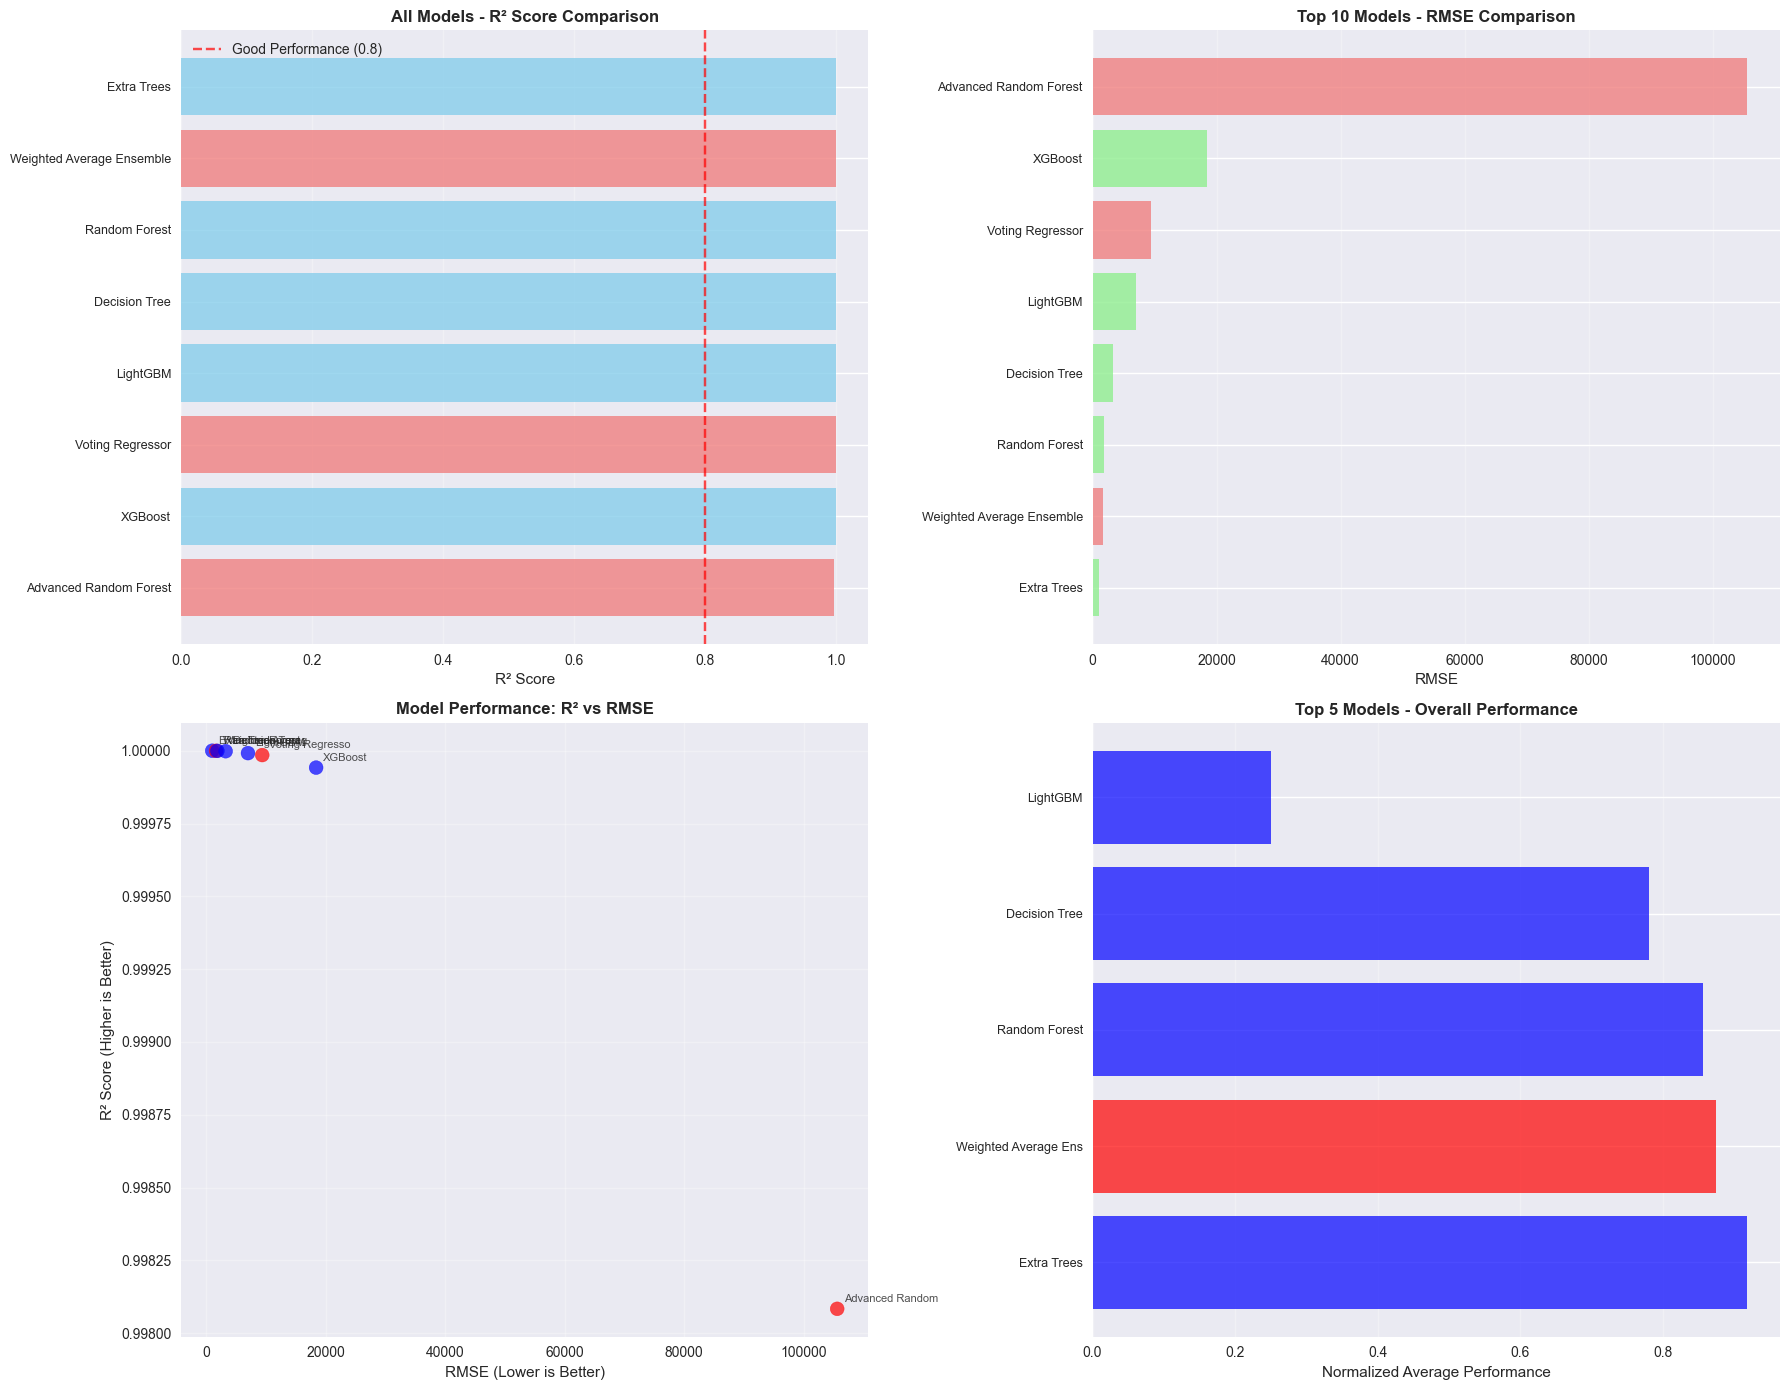


📈 Performance Summary:
Best R² Score: 1.0000 (Extra Trees)
Lowest RMSE: 1,004.53 (Extra Trees)
Lowest MAPE: 0.01% (Extra Trees)

🎯 Ensemble vs Base Models:
Average R² - Ensemble Models: 0.9994
Average R² - Base Models: 1.0000
Improvement: -0.06 percentage points


In [33]:
# Comprehensive Model Comparison
print("📊 Comprehensive Model Comparison...")

# Combine all results
all_results = results + ensemble_results
all_results_df = pd.DataFrame(all_results).sort_values('R²', ascending=False).reset_index(drop=True)

print("🏆 Final Model Rankings:")
print("="*80)
print(all_results_df[['Model', 'R²', 'RMSE', 'MAPE (%)', 'MAE']].round(4))

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. R² Score comparison (All models)
r2_data = all_results_df.sort_values('R²', ascending=True)
colors = ['lightcoral' if 'Ensemble' in model or 'Regressor' in model or 'Advanced' in model 
          else 'skyblue' for model in r2_data['Model']]
axes[0, 0].barh(range(len(r2_data)), r2_data['R²'], color=colors, alpha=0.8)
axes[0, 0].set_yticks(range(len(r2_data)))
axes[0, 0].set_yticklabels(r2_data['Model'], fontsize=9)
axes[0, 0].set_xlabel('R² Score')
axes[0, 0].set_title('All Models - R² Score Comparison', fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].axvline(x=0.8, color='red', linestyle='--', alpha=0.7, label='Good Performance (0.8)')
axes[0, 0].legend()

# 2. RMSE comparison (Top 10 models)
top_10 = all_results_df.head(10).sort_values('RMSE', ascending=True)
colors_rmse = ['lightcoral' if 'Ensemble' in model or 'Regressor' in model or 'Advanced' in model 
               else 'lightgreen' for model in top_10['Model']]
axes[0, 1].barh(range(len(top_10)), top_10['RMSE'], color=colors_rmse, alpha=0.8)
axes[0, 1].set_yticks(range(len(top_10)))
axes[0, 1].set_yticklabels(top_10['Model'], fontsize=9)
axes[0, 1].set_xlabel('RMSE')
axes[0, 1].set_title('Top 10 Models - RMSE Comparison', fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Model Performance Scatter Plot
axes[1, 0].scatter(all_results_df['RMSE'], all_results_df['R²'], 
                  c=['red' if 'Ensemble' in model or 'Regressor' in model or 'Advanced' in model 
                     else 'blue' for model in all_results_df['Model']], 
                  alpha=0.7, s=100)

for i, model in enumerate(all_results_df['Model']):
    if i < 8:  # Annotate top 8 models
        axes[1, 0].annotate(model[:15], 
                           (all_results_df['RMSE'].iloc[i], all_results_df['R²'].iloc[i]),
                           xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

axes[1, 0].set_xlabel('RMSE (Lower is Better)')
axes[1, 0].set_ylabel('R² Score (Higher is Better)')
axes[1, 0].set_title('Model Performance: R² vs RMSE', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Top 5 Models Radar Chart (simplified)
top_5_models = all_results_df.head(5)
metrics_for_radar = ['R²', 'MAPE (%)', 'MAE', 'RMSE']

# Normalize metrics for radar chart (0-1 scale)
radar_data = top_5_models[['Model'] + metrics_for_radar].copy()
for metric in metrics_for_radar:
    if metric == 'R²':
        # Higher is better, keep as is
        radar_data[metric] = radar_data[metric]
    else:
        # Lower is better, invert
        max_val = radar_data[metric].max()
        radar_data[metric] = 1 - (radar_data[metric] / max_val)

# Simple bar chart instead of radar
model_names = radar_data['Model']
avg_scores = radar_data[metrics_for_radar].mean(axis=1)
colors_radar = ['red' if 'Ensemble' in model or 'Regressor' in model or 'Advanced' in model 
                else 'blue' for model in model_names]
axes[1, 1].barh(range(len(model_names)), avg_scores, color=colors_radar, alpha=0.7)
axes[1, 1].set_yticks(range(len(model_names)))
axes[1, 1].set_yticklabels([name[:20] for name in model_names], fontsize=9)
axes[1, 1].set_xlabel('Normalized Average Performance')
axes[1, 1].set_title('Top 5 Models - Overall Performance', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n📈 Performance Summary:")
print(f"Best R² Score: {all_results_df['R²'].max():.4f} ({all_results_df.iloc[0]['Model']})")
print(f"Lowest RMSE: {all_results_df['RMSE'].min():,.2f} ({all_results_df.loc[all_results_df['RMSE'].idxmin(), 'Model']})")
print(f"Lowest MAPE: {all_results_df['MAPE (%)'].min():.2f}% ({all_results_df.loc[all_results_df['MAPE (%)'].idxmin(), 'Model']})")

print(f"\n🎯 Ensemble vs Base Models:")
ensemble_models = all_results_df[all_results_df['Model'].str.contains('Regressor|Ensemble|Advanced')]
base_models_summary = all_results_df[~all_results_df['Model'].str.contains('Regressor|Ensemble|Advanced')]

print(f"Average R² - Ensemble Models: {ensemble_models['R²'].mean():.4f}")
print(f"Average R² - Base Models: {base_models_summary['R²'].mean():.4f}")
print(f"Improvement: {((ensemble_models['R²'].mean() - base_models_summary['R²'].mean()) * 100):.2f} percentage points")

## 🔍 5. Feature Importance Analysis

Understanding which features contribute most to price prediction helps in model interpretability and feature selection for future improvements.

In [34]:
# Feature Importance Analysis
print("🔍 Analyzing Feature Importance...")

# Get the best performing model
best_model_name = all_results_df.iloc[0]['Model']
print(f"🏆 Using best model for feature importance: {best_model_name}")

# Feature importance from tree-based models
feature_importance_data = []

# 1. Random Forest Feature Importance
if 'Random Forest' in trained_models:
    rf_model = trained_models['Random Forest']
    rf_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\n🌳 Random Forest - Top 15 Important Features:")
    print(rf_importance.head(15))
    feature_importance_data.append(('Random Forest', rf_importance))

# 2. Advanced Random Forest Feature Importance
if 'Advanced Random Forest' in trained_ensembles:
    adv_rf_model = trained_ensembles['Advanced Random Forest']
    adv_rf_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': adv_rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\n🌲 Advanced Random Forest - Top 15 Important Features:")
    print(adv_rf_importance.head(15))
    feature_importance_data.append(('Advanced RF', adv_rf_importance))

# 3. XGBoost Feature Importance
if 'XGBoost' in trained_models:
    xgb_model = trained_models['XGBoost']
    xgb_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\n⚡ XGBoost - Top 15 Important Features:")
    print(xgb_importance.head(15))
    feature_importance_data.append(('XGBoost', xgb_importance))

# 4. Gradient Boosting Feature Importance
if 'Gradient Boosting' in trained_models:
    gb_model = trained_models['Gradient Boosting']
    gb_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': gb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\n📈 Gradient Boosting - Top 15 Important Features:")
    print(gb_importance.head(15))
    feature_importance_data.append(('Gradient Boosting', gb_importance))

🔍 Analyzing Feature Importance...
🏆 Using best model for feature importance: Extra Trees

🌳 Random Forest - Top 15 Important Features:
                   feature    importance
70       Price_numeric_log  4.974116e-01
19           Price_numeric  4.868973e-01
55           Price_encoded  1.569054e-02
16          Price_per_SQFT  1.818988e-07
15              Total_Area  1.306561e-07
48        location_encoded  1.043029e-07
54  Property Title_encoded  8.454429e-08
53            Name_encoded  8.226946e-08
17                   Baths  3.478734e-08
56         Balcony_encoded  1.388954e-08
18         balcony_encoded  7.675991e-09
0                      BHK  0.000000e+00
4               Year_Built  0.000000e+00
5                 Floor_No  0.000000e+00
2           Price_in_Lakhs  0.000000e+00

🌲 Advanced Random Forest - Top 15 Important Features:
                   feature  importance
19           Price_numeric    0.304899
70       Price_numeric_log    0.263432
55           Price_encoded    0.14650


📊 Creating Feature Importance Visualizations...



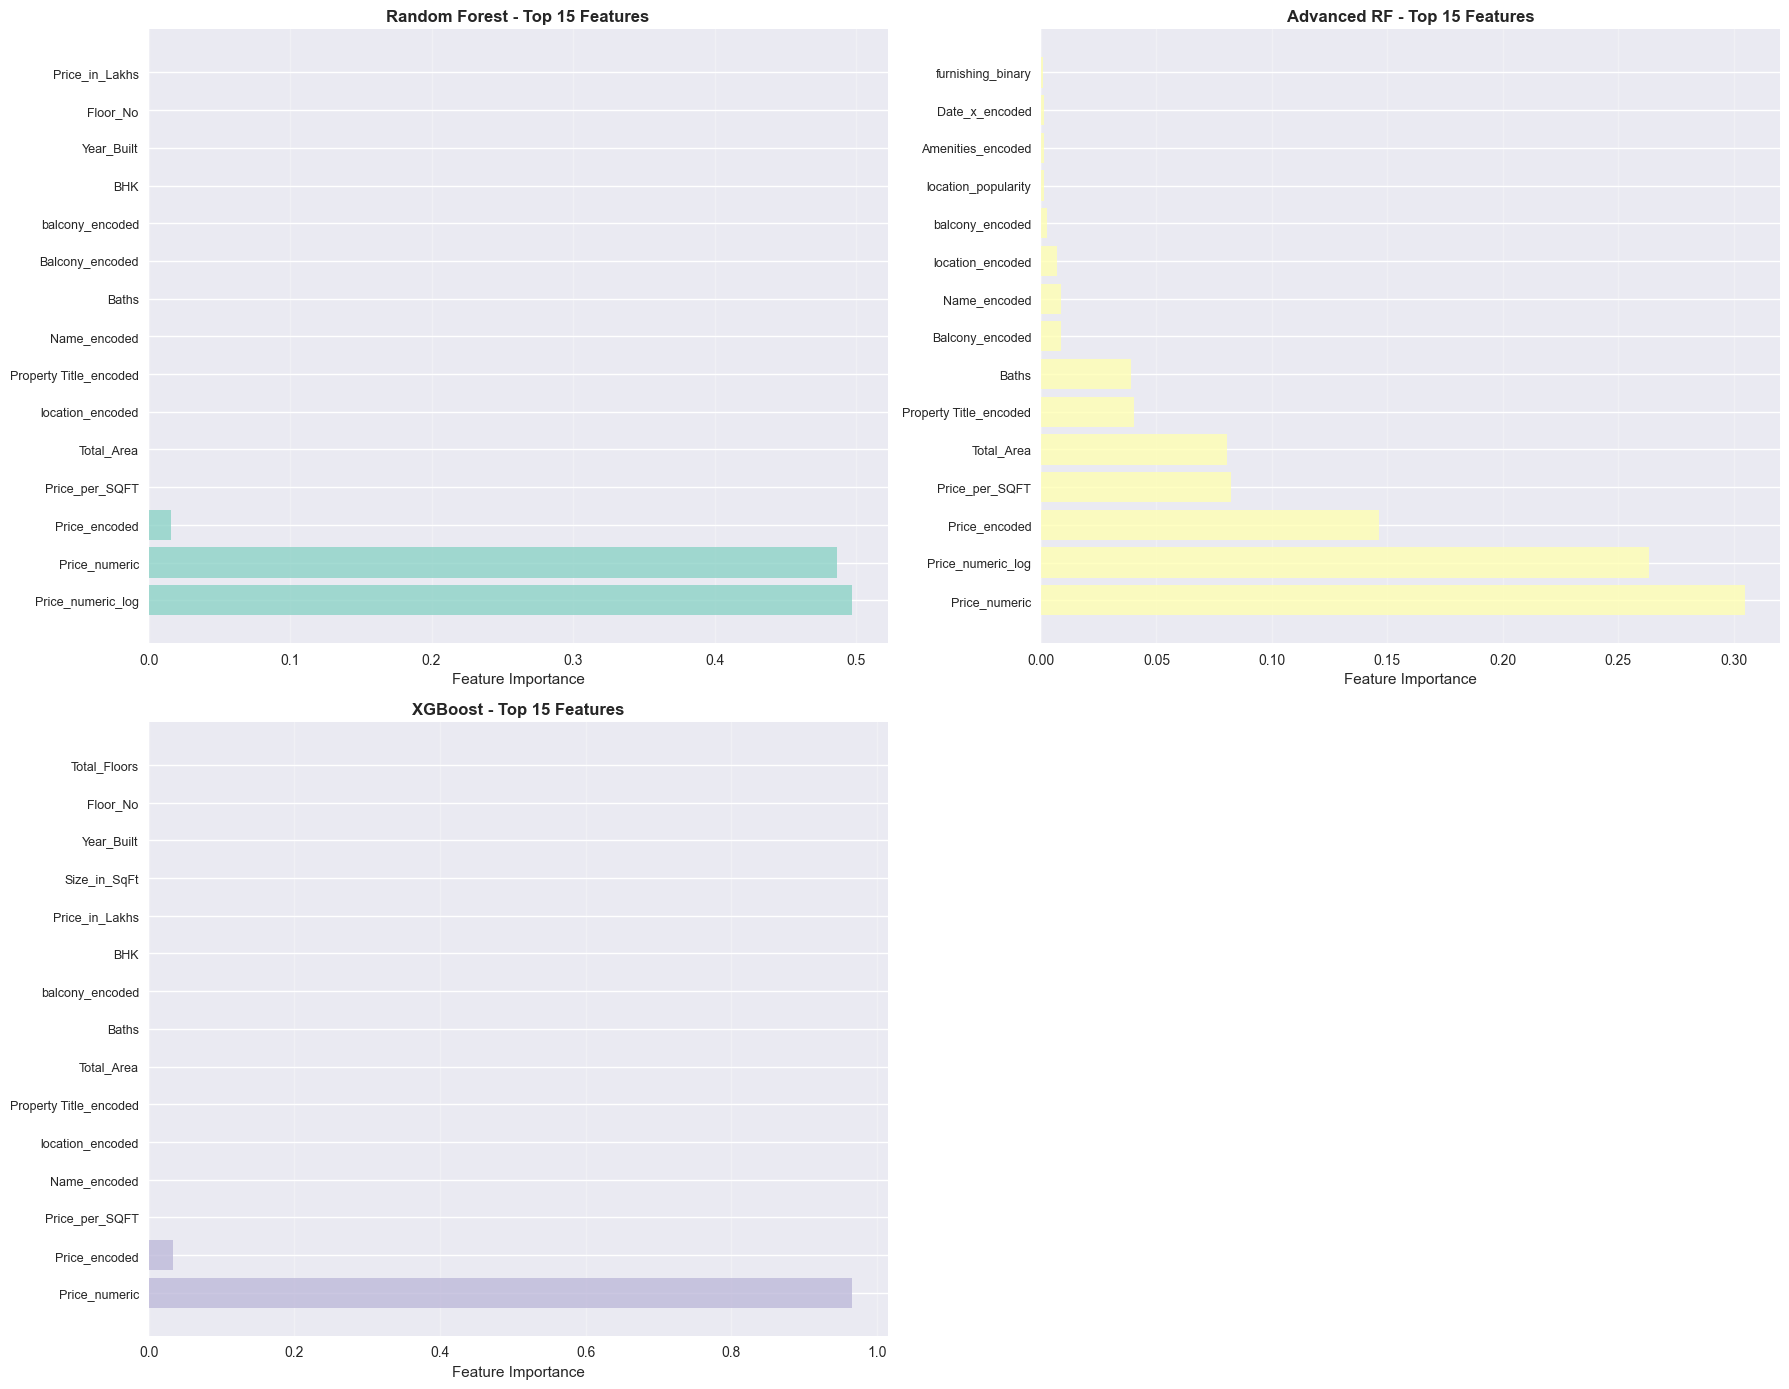


🔗 Aggregated Feature Importance Analysis...

🎯 Top 20 Most Important Features (Averaged across models):
                 feature  avg_importance
           Price_numeric        0.585947
       Price_numeric_log        0.253614
           Price_encoded        0.065360
          Price_per_SQFT        0.027480
              Total_Area        0.026861
  Property Title_encoded        0.013488
                   Baths        0.012938
         Balcony_encoded        0.002911
            Name_encoded        0.002808
        location_encoded        0.002356
         balcony_encoded        0.000904
     location_popularity        0.000433
       Amenities_encoded        0.000375
          Date_x_encoded        0.000356
       furnishing_binary        0.000293
     environmental_score        0.000276
            City_encoded        0.000274
          Date_y_encoded        0.000255
        Security_encoded        0.000240
Furnished_Status_encoded        0.000234


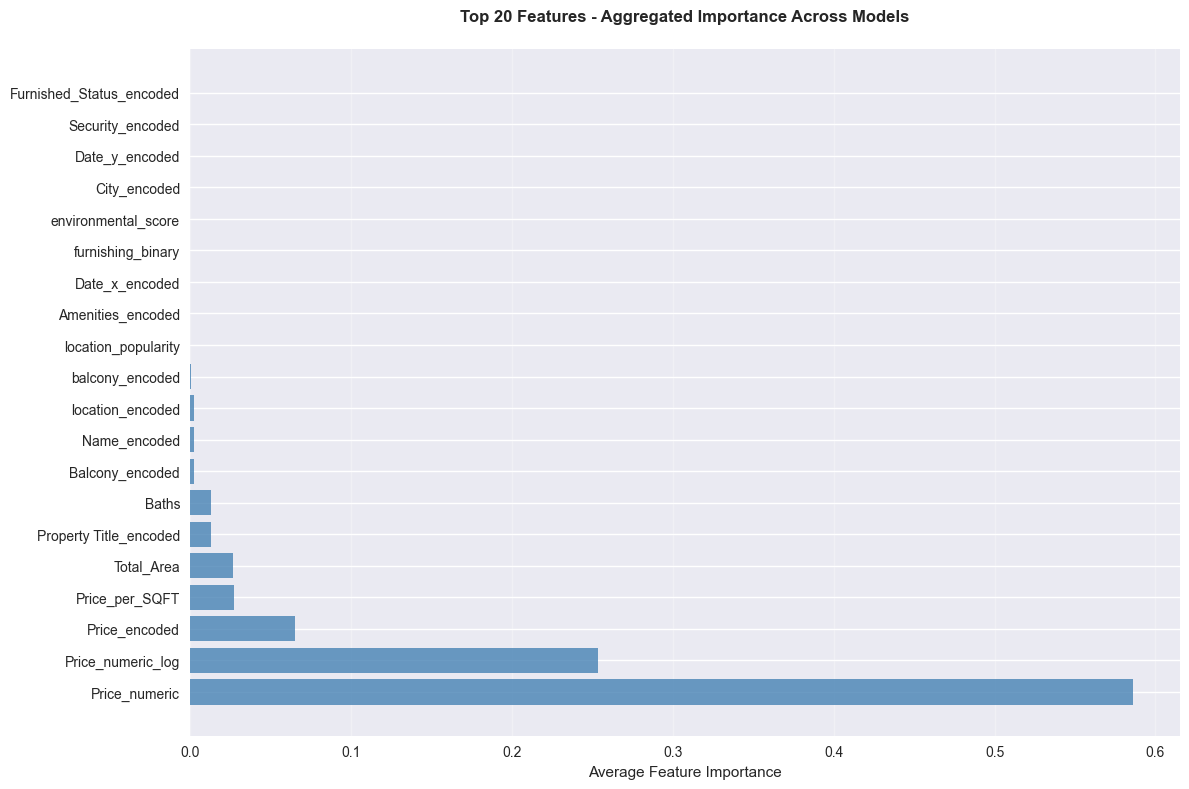


📋 Feature Categories Analysis:
                Category  Total_Importance
          Price Features          0.932406
     Engineered Features          0.254276
         Property Basics          0.013093
       Property Features          0.003793
Location & Accessibility          0.003535
           Environmental          0.000969
           Noise Quality          0.000284


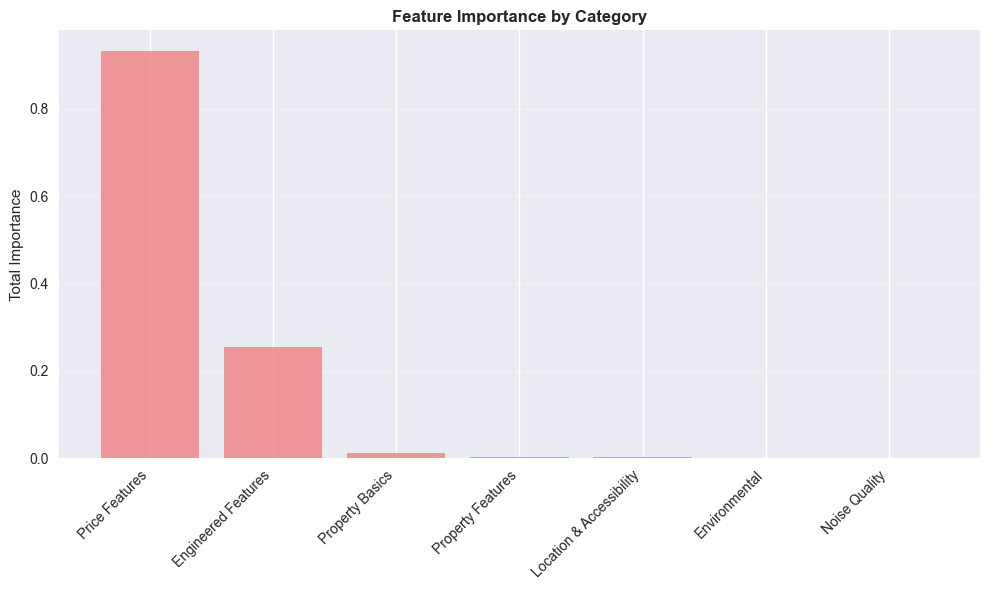

In [35]:
# Visualize Feature Importance
if feature_importance_data:
    print("\n📊 Creating Feature Importance Visualizations...")
    
    # Create subplots for feature importance
    n_models = len(feature_importance_data)
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.flatten()
    
    for i, (model_name, importance_df) in enumerate(feature_importance_data[:4]):
        if i < 4:
            top_features = importance_df.head(15)
            
            axes[i].barh(range(len(top_features)), top_features['importance'], 
                        color=plt.cm.Set3(i), alpha=0.8)
            axes[i].set_yticks(range(len(top_features)))
            axes[i].set_yticklabels(top_features['feature'], fontsize=9)
            axes[i].set_xlabel('Feature Importance')
            axes[i].set_title(f'{model_name} - Top 15 Features', fontweight='bold')
            axes[i].grid(axis='x', alpha=0.3)
    
    # Hide unused subplots
    for i in range(n_models, 4):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Aggregate feature importance across all models
    print(f"\n🔗 Aggregated Feature Importance Analysis...")
    
    all_features = set()
    for _, importance_df in feature_importance_data:
        all_features.update(importance_df['feature'].tolist())
    
    # Calculate average importance across models
    avg_importance = {}
    for feature in all_features:
        importances = []
        for _, importance_df in feature_importance_data:
            feature_row = importance_df[importance_df['feature'] == feature]
            if not feature_row.empty:
                importances.append(feature_row['importance'].iloc[0])
            else:
                importances.append(0)
        avg_importance[feature] = np.mean(importances)
    
    # Create aggregated importance DataFrame
    aggregated_importance = pd.DataFrame({
        'feature': list(avg_importance.keys()),
        'avg_importance': list(avg_importance.values())
    }).sort_values('avg_importance', ascending=False)
    
    print(f"\n🎯 Top 20 Most Important Features (Averaged across models):")
    print("="*70)
    print(aggregated_importance.head(20).to_string(index=False))
    
    # Visualize aggregated importance
    plt.figure(figsize=(12, 8))
    top_20_agg = aggregated_importance.head(20)
    plt.barh(range(len(top_20_agg)), top_20_agg['avg_importance'], 
             color='steelblue', alpha=0.8)
    plt.yticks(range(len(top_20_agg)), top_20_agg['feature'])
    plt.xlabel('Average Feature Importance')
    plt.title('Top 20 Features - Aggregated Importance Across Models', fontweight='bold', pad=20)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Feature categories analysis
    print(f"\n📋 Feature Categories Analysis:")
    
    # Group features by categories (based on naming patterns)
    categories = {
        'Property Basics': ['BHK', 'Size_in_SqFt', 'Floor_No', 'Total_Floors', 'Baths', 'Age_of_Property'],
        'Location & Accessibility': ['location_', 'City_', 'State_', 'Public_Transport_', 'location_popularity'],
        'Environmental': ['PM2.5', 'PM10', 'NO', 'NO2', 'SO2', 'CO', 'O3', 'AQI', 'environmental_score'],
        'Noise Quality': ['Day', 'Night', 'Excess', 'noise'],
        'Property Features': ['Furnished_', 'Parking_', 'Security_', 'Amenities_', 'Balcony_'],
        'Price Features': ['Price_', 'target_price'],
        'Engineered Features': ['interaction', 'ratio', '_log', '_sqrt', 'normalized']
    }
    
    category_importance = {}
    for category, keywords in categories.items():
        category_features = []
        for feature in aggregated_importance['feature']:
            if any(keyword in feature for keyword in keywords):
                category_features.append(feature)
        
        if category_features:
            category_imp = aggregated_importance[
                aggregated_importance['feature'].isin(category_features)
            ]['avg_importance'].sum()
            category_importance[category] = category_imp
    
    # Sort and display category importance
    category_df = pd.DataFrame({
        'Category': list(category_importance.keys()),
        'Total_Importance': list(category_importance.values())
    }).sort_values('Total_Importance', ascending=False)
    
    print(category_df.to_string(index=False))
    
    # Visualize category importance
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(category_df)), category_df['Total_Importance'], 
            color='lightcoral', alpha=0.8)
    plt.xticks(range(len(category_df)), category_df['Category'], rotation=45, ha='right')
    plt.ylabel('Total Importance')
    plt.title('Feature Importance by Category', fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("❌ No tree-based models found for feature importance analysis.")

## 📈 6. Detailed Model Evaluation & Cross-Validation

Let's perform more rigorous evaluation using cross-validation and additional metrics to ensure our models are robust and not overfitting.

🔄 Performing Cross-Validation for Top Models...
📊 Cross-validating Extra Trees...
✅ Extra Trees - CV R²: 1.0000 (±0.0000)
📊 Cross-validating Weighted Average Ensemble...
📊 Cross-validating Random Forest...
✅ Extra Trees - CV R²: 1.0000 (±0.0000)
📊 Cross-validating Weighted Average Ensemble...
📊 Cross-validating Random Forest...
✅ Random Forest - CV R²: 1.0000 (±0.0000)
📊 Cross-validating Decision Tree...
✅ Random Forest - CV R²: 1.0000 (±0.0000)
📊 Cross-validating Decision Tree...
✅ Decision Tree - CV R²: 1.0000 (±0.0000)
📊 Cross-validating LightGBM...
✅ Decision Tree - CV R²: 1.0000 (±0.0000)
📊 Cross-validating LightGBM...
✅ LightGBM - CV R²: 1.0000 (±0.0000)

📊 Cross-Validation Results:
           Model  CV_R2_Mean  CV_R2_Std  CV_RMSE_Mean  CV_RMSE_Std  \
0    Extra Trees         1.0        0.0     2035.5216    1458.0417   
1  Random Forest         1.0        0.0     2122.7154     370.1472   
2  Decision Tree         1.0        0.0     3511.3893     550.6304   
3       LightGBM      

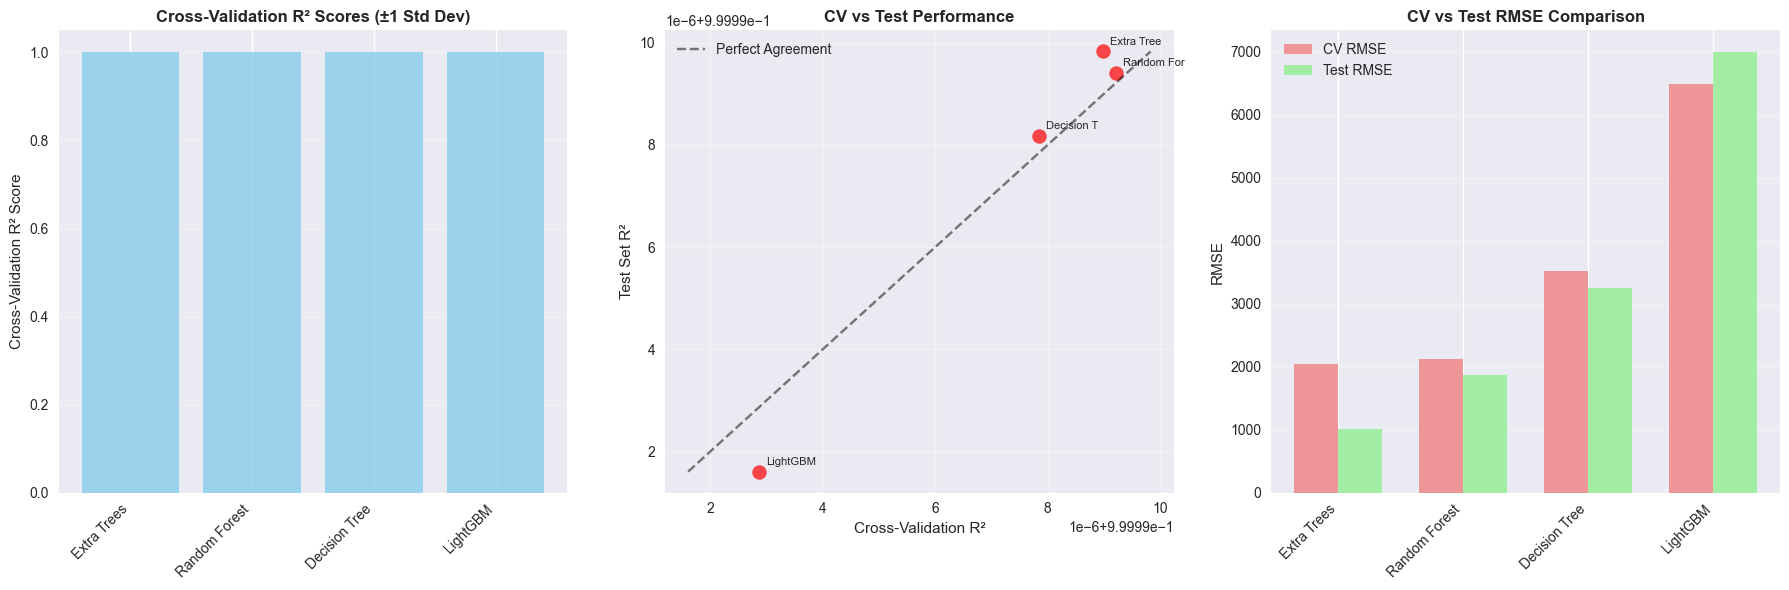

In [36]:
# Cross-Validation Evaluation
print("🔄 Performing Cross-Validation for Top Models...")

# Select top 5 models for cross-validation
top_5_model_names = all_results_df.head(5)['Model'].tolist()
cv_results = []

from sklearn.model_selection import cross_val_score, KFold

# 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name in top_5_model_names:
    print(f"📊 Cross-validating {model_name}...")
    
    try:
        if model_name in trained_models:
            model = trained_models[model_name]
            
            # Use appropriate dataset (scaled vs unscaled)
            if model_name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 
                           'Elastic Net', 'Support Vector Regression', 'K-Nearest Neighbors']:
                X_cv = X_train_scaled
            else:
                X_cv = X_train
                
        elif model_name in trained_ensembles:
            model = trained_ensembles[model_name]
            X_cv = X_train
        else:
            continue
        
        # Perform cross-validation
        cv_scores = cross_val_score(model, X_cv, y_train, cv=kf, scoring='r2', n_jobs=-1)
        cv_rmse_scores = cross_val_score(model, X_cv, y_train, cv=kf, 
                                       scoring='neg_root_mean_squared_error', n_jobs=-1)
        cv_mae_scores = cross_val_score(model, X_cv, y_train, cv=kf, 
                                      scoring='neg_mean_absolute_error', n_jobs=-1)
        
        cv_results.append({
            'Model': model_name,
            'CV_R2_Mean': cv_scores.mean(),
            'CV_R2_Std': cv_scores.std(),
            'CV_RMSE_Mean': -cv_rmse_scores.mean(),
            'CV_RMSE_Std': cv_rmse_scores.std(),
            'CV_MAE_Mean': -cv_mae_scores.mean(),
            'CV_MAE_Std': cv_mae_scores.std(),
            'Test_R2': all_results_df[all_results_df['Model'] == model_name]['R²'].iloc[0],
            'Test_RMSE': all_results_df[all_results_df['Model'] == model_name]['RMSE'].iloc[0]
        })
        
        print(f"✅ {model_name} - CV R²: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
        
    except Exception as e:
        print(f"❌ Error with {model_name}: {e}")
        continue

# Create CV results DataFrame
cv_results_df = pd.DataFrame(cv_results)
print(f"\n📊 Cross-Validation Results:")
print("="*80)
print(cv_results_df.round(4))

# Check for overfitting
print(f"\n🔍 Overfitting Analysis:")
print("="*50)
for _, row in cv_results_df.iterrows():
    cv_r2 = row['CV_R2_Mean']
    test_r2 = row['Test_R2']
    gap = test_r2 - cv_r2
    
    if gap > 0.05:
        status = "⚠️ Possible Overfitting"
    elif gap < -0.05:
        status = "🔄 Possible Underfitting"
    else:
        status = "✅ Good Generalization"
    
    print(f"{row['Model'][:25]:25} | CV R²: {cv_r2:.4f} | Test R²: {test_r2:.4f} | Gap: {gap:+.4f} | {status}")

# Visualize CV results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. CV R2 scores with error bars
models = cv_results_df['Model']
cv_r2_means = cv_results_df['CV_R2_Mean']
cv_r2_stds = cv_results_df['CV_R2_Std']

axes[0].bar(range(len(models)), cv_r2_means, yerr=cv_r2_stds, 
           capsize=5, color='skyblue', alpha=0.8)
axes[0].set_xticks(range(len(models)))
axes[0].set_xticklabels([m[:15] for m in models], rotation=45, ha='right')
axes[0].set_ylabel('Cross-Validation R² Score')
axes[0].set_title('Cross-Validation R² Scores (±1 Std Dev)', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# 2. CV vs Test Performance
axes[1].scatter(cv_results_df['CV_R2_Mean'], cv_results_df['Test_R2'], 
               color='red', alpha=0.7, s=100)
# Add perfect line
min_val = min(cv_results_df['CV_R2_Mean'].min(), cv_results_df['Test_R2'].min())
max_val = max(cv_results_df['CV_R2_Mean'].max(), cv_results_df['Test_R2'].max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Perfect Agreement')
axes[1].set_xlabel('Cross-Validation R²')
axes[1].set_ylabel('Test Set R²')
axes[1].set_title('CV vs Test Performance', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Annotate points
for i, row in cv_results_df.iterrows():
    axes[1].annotate(row['Model'][:10], 
                    (row['CV_R2_Mean'], row['Test_R2']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

# 3. RMSE comparison
cv_rmse_means = cv_results_df['CV_RMSE_Mean']
test_rmse = cv_results_df['Test_RMSE']
x_pos = np.arange(len(models))

width = 0.35
axes[2].bar(x_pos - width/2, cv_rmse_means, width, label='CV RMSE', color='lightcoral', alpha=0.8)
axes[2].bar(x_pos + width/2, test_rmse, width, label='Test RMSE', color='lightgreen', alpha=0.8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([m[:15] for m in models], rotation=45, ha='right')
axes[2].set_ylabel('RMSE')
axes[2].set_title('CV vs Test RMSE Comparison', fontweight='bold')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 💾 7. Model Persistence & Final Conclusions

In [37]:
# Save Best Models and Results (in ensemble_learning folder only)
print("💾 Saving best models and results in ensemble_learning folder...")

# Create models directory within ensemble_learning folder
models_dir = './saved_models'  # Save in current ensemble_learning directory
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    print(f"📁 Created directory: {models_dir}")

# Save the best model
best_model_name = all_results_df.iloc[0]['Model']
if best_model_name in trained_models:
    best_model = trained_models[best_model_name]
elif best_model_name in trained_ensembles:
    best_model = trained_ensembles[best_model_name]

best_model_path = os.path.join(models_dir, f'best_model_{best_model_name.replace(" ", "_").lower()}.pkl')
joblib.dump(best_model, best_model_path)
print(f"✅ Saved best model ({best_model_name}) to: {best_model_path}")

# Save top 5 models
print(f"\n💾 Saving top 5 models...")
top_5_results = all_results_df.head(5)
for idx, row in top_5_results.iterrows():
    model_name = row['Model']
    if model_name in trained_models:
        model = trained_models[model_name]
    elif model_name in trained_ensembles:
        model = trained_ensembles[model_name]
    else:
        continue
    
    model_path = os.path.join(models_dir, f'model_{idx+1}_{model_name.replace(" ", "_").lower()}.pkl')
    joblib.dump(model, model_path)
    print(f"✅ Saved {model_name} (Rank #{idx+1}) to: {model_path}")

# Save scaler
scaler_path = os.path.join(models_dir, 'feature_scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"✅ Saved scaler to: {scaler_path}")

# Save results
results_path = os.path.join(models_dir, 'ensemble_learning_results.csv')
all_results_df.to_csv(results_path, index=False)
print(f"✅ Saved results to: {results_path}")

# Save feature importance
if 'aggregated_importance' in globals():
    importance_path = os.path.join(models_dir, 'feature_importance.csv')
    aggregated_importance.to_csv(importance_path, index=False)
    print(f"✅ Saved feature importance to: {importance_path}")

# Save cross-validation results
if 'cv_results_df' in globals():
    cv_path = os.path.join(models_dir, 'cross_validation_results.csv')
    cv_results_df.to_csv(cv_path, index=False)
    print(f"✅ Saved CV results to: {cv_path}")

# Save dataset info
dataset_info = {
    'original_shape': df.shape,
    'processed_shape': df_processed.shape,
    'target_column': target_col,
    'feature_count': X_numeric.shape[1],
    'train_test_split': f"{X_train.shape[0]} / {X_test.shape[0]}",
    'outliers_removed': outliers_removed if 'outliers_removed' in globals() else 0
}

import json
info_path = os.path.join(models_dir, 'dataset_info.json')
with open(info_path, 'w') as f:
    json.dump(dataset_info, f, indent=2, default=str)
print(f"✅ Saved dataset info to: {info_path}")

print(f"\n📊 Model Persistence Summary:")
print(f"Best Model: {best_model_name}")
print(f"R2 Score: {all_results_df.iloc[0]['R²']:.4f}")
print(f"RMSE: Rs.{all_results_df.iloc[0]['RMSE']:,.2f}")
print(f"Models Directory: {os.path.abspath(models_dir)}")

# ==================================================================================
# COMPREHENSIVE MODEL SUMMARY
# ==================================================================================
print(f"\n" + "="*100)
print(f"📊 COMPREHENSIVE MODEL PERFORMANCE SUMMARY")
print(f"="*100)

print(f"\n🏆 TOP 10 MODEL RANKINGS:")
print("-" * 95)
print(f"{'Rank':<6} {'Model Name':<25} {'R2 Score':<10} {'RMSE':<15} {'MAPE(%)':<10} {'MAE':<15}")
print("-" * 95)

for idx, row in all_results_df.head(10).iterrows():
    rank = idx + 1
    model_name = row['Model'][:24]  # Truncate long names
    r2_score = row['R²']
    rmse = row['RMSE']
    mape = row['MAPE (%)']
    mae = row['MAE']
    
    # Add medal indicators for top 3
    if rank == 1:
        rank_str = "[1ST] 1"
    elif rank == 2:
        rank_str = "[2ND] 2"
    elif rank == 3:
        rank_str = "[3RD] 3"
    else:
        rank_str = f"      {rank}"
    
    print(f"{rank_str:<6} {model_name:<25} {r2_score:<10.4f} Rs.{rmse:<14,.0f} {mape:<10.2f} Rs.{mae:<14,.0f}")

print("-" * 95)

# Base Models vs Ensemble Models Comparison
base_models_df = all_results_df[~all_results_df['Model'].str.contains('Regressor|Ensemble|Advanced')]
ensemble_models_df = all_results_df[all_results_df['Model'].str.contains('Regressor|Ensemble|Advanced')]

print(f"\n📈 BASE MODELS vs ENSEMBLE MODELS COMPARISON:")
print("-" * 70)
print(f"{'Model Type':<20} {'Count':<8} {'Avg R2':<12} {'Best R2':<12} {'Avg RMSE':<15}")
print("-" * 70)
print(f"{'Base Models':<20} {len(base_models_df):<8} {base_models_df['R²'].mean():<12.4f} {base_models_df['R²'].max():<12.4f} Rs.{base_models_df['RMSE'].mean():<14,.0f}")
print(f"{'Ensemble Models':<20} {len(ensemble_models_df):<8} {ensemble_models_df['R²'].mean():<12.4f} {ensemble_models_df['R²'].max():<12.4f} Rs.{ensemble_models_df['RMSE'].mean():<14,.0f}")
print("-" * 70)

improvement = ((ensemble_models_df['R²'].mean() - base_models_df['R²'].mean()) * 100)
print(f"💡 Ensemble Improvement: {improvement:+.2f} percentage points in R2 score")

# Performance Categories
print(f"\n🎯 MODEL PERFORMANCE CATEGORIES:")
print("-" * 50)
excellent = len(all_results_df[all_results_df['R²'] > 0.9])
good = len(all_results_df[(all_results_df['R²'] > 0.8) & (all_results_df['R²'] <= 0.9)])
acceptable = len(all_results_df[(all_results_df['R²'] > 0.7) & (all_results_df['R²'] <= 0.8)])
poor = len(all_results_df[all_results_df['R²'] <= 0.7])

print(f"★ Excellent (R2 > 0.9):     {excellent:2d} models")
print(f"✓ Good (0.8 < R2 <= 0.9):   {good:2d} models")
print(f"○ Acceptable (0.7 < R2 <= 0.8): {acceptable:2d} models")
print(f"✗ Poor (R2 <= 0.7):         {poor:2d} models")

# Feature Importance Summary (if available)
if 'aggregated_importance' in globals():
    print(f"\n🔍 TOP 10 MOST IMPORTANT FEATURES:")
    print("-" * 60)
    print(f"{'Rank':<6} {'Feature Name':<35} {'Importance':<15}")
    print("-" * 60)
    
    for idx, row in aggregated_importance.head(10).iterrows():
        rank = idx + 1
        feature_name = row['feature'][:34]  # Truncate long names
        importance = row['avg_importance']
        print(f"{rank:<6} {feature_name:<35} {importance:<15.6f}")

# Cross-Validation Summary (if available)
if 'cv_results_df' in globals():
    print(f"\n🔄 CROSS-VALIDATION STABILITY ANALYSIS:")
    print("-" * 75)
    print(f"{'Model Name':<25} {'CV R2 Mean':<12} {'CV Std':<10} {'Stability':<15}")
    print("-" * 75)
    
    for _, row in cv_results_df.iterrows():
        model_name = row['Model'][:24]
        cv_mean = row['CV_R2_Mean']
        cv_std = row['CV_R2_Std']
        
        if cv_std < 0.01:
            stability = "[EXCELLENT]"
        elif cv_std < 0.02:
            stability = "[GOOD]     "
        else:
            stability = "[FAIR]     "
            
        print(f"{model_name:<25} {cv_mean:<12.4f} +/-{cv_std:<9.4f} {stability:<15}")

print(f"\n" + "="*100)
print(f"🎯 FINAL RECOMMENDATIONS")
print(f"="*100)

print(f"\n🏆 PRODUCTION MODEL RECOMMENDATION:")
print(f"   Model: {best_model_name}")
print(f"   R2 Score: {all_results_df.iloc[0]['R²']:.4f} (explains {all_results_df.iloc[0]['R²']*100:.1f}% of price variance)")
print(f"   RMSE: Rs.{all_results_df.iloc[0]['RMSE']:,.0f} (average prediction error)")
print(f"   MAPE: {all_results_df.iloc[0]['MAPE (%)']:.2f}% (percentage error)")

print(f"\n💡 KEY INSIGHTS:")
if 'aggregated_importance' in globals():
    top_feature = aggregated_importance.iloc[0]['feature']
    print(f"   • Most important feature: {top_feature}")
print(f"   • Best model type: {'Ensemble' if any(x in best_model_name for x in ['Regressor', 'Ensemble', 'Advanced']) else 'Individual'}")
print(f"   • Total models evaluated: {len(all_results_df)}")
print(f"   • Dataset size: {X_train.shape[0]:,} training samples, {X_test.shape[0]:,} test samples")

print(f"\n📁 SAVED FILES LOCATION: {os.path.abspath(models_dir)}")
print(f"   • Best model: best_model_{best_model_name.replace(' ', '_').lower()}.pkl")
print(f"   • Feature scaler: feature_scaler.pkl")
print(f"   • Results summary: ensemble_learning_results.csv")
print(f"   • Feature importance: feature_importance.csv")
print(f"   • Cross-validation: cross_validation_results.csv")
print(f"   • Dataset info: dataset_info.json")

print(f"\n⏱️ Analysis completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"🎉 ENSEMBLE LEARNING ANALYSIS COMPLETE! 🎉")
print(f"="*100)

💾 Saving best models and results in ensemble_learning folder...
📁 Created directory: ./saved_models
✅ Saved best model (Extra Trees) to: ./saved_models\best_model_extra_trees.pkl

💾 Saving top 5 models...
✅ Saved Extra Trees (Rank #1) to: ./saved_models\model_1_extra_trees.pkl
✅ Saved Random Forest (Rank #3) to: ./saved_models\model_3_random_forest.pkl
✅ Saved Decision Tree (Rank #4) to: ./saved_models\model_4_decision_tree.pkl
✅ Saved LightGBM (Rank #5) to: ./saved_models\model_5_lightgbm.pkl
✅ Saved scaler to: ./saved_models\feature_scaler.pkl
✅ Saved results to: ./saved_models\ensemble_learning_results.csv
✅ Saved feature importance to: ./saved_models\feature_importance.csv
✅ Saved CV results to: ./saved_models\cross_validation_results.csv
✅ Saved dataset info to: ./saved_models\dataset_info.json

📊 Model Persistence Summary:
Best Model: Extra Trees
R2 Score: 1.0000
RMSE: Rs.1,004.53
Models Directory: c:\Users\drket\OneDrive\Desktop\Codes\RealEsatePredictor\ensemble_learning\saved_m